In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path

#  1. Dataset Summary 
raw = pd.read_csv("../data/raw/crashes_raw.csv", low_memory=False)
cleaned = pd.read_csv("../data/processed/crashes_cleaned.csv")
segment_risk = pd.read_csv("../data/processed/segment_risk.csv")

print("        URBAN CRASH ANALYTICS — RESULTS")

print("\n── DATASET SUMMARY ──")
print(f"Raw crash records downloaded:    {len(raw):,}")
print(f"After cleaning (usable):         {len(cleaned):,}")
print(f"Records dropped (no GPS):        {len(raw)-len(cleaned):,}  (7.7%)")
print(f"Road segments in NYC:            122,272")
print(f"Road segments with crash data:   {len(segment_risk):,}")
print(f"Date range covered:              Feb 2021 – Mar 2026")

print("\n── COLLISION SEVERITY INDEX ──")
print(f"Total CSI across all crashes:    {cleaned['csi'].sum():,.0f}")
print(f"Average CSI per crash:           {cleaned['csi'].mean():.2f}")
print(f"Max CSI single crash:            {cleaned['csi'].max():.0f}")
print(f"Crashes with injuries/fatalities:{(cleaned['csi'] > 1).sum():,}  ({(cleaned['csi']>1).mean()*100:.1f}%)")
print(f"Total injuries recorded:         {cleaned['number_of_persons_injured'].sum():,}")
print(f"Total fatalities recorded:       {cleaned['number_of_persons_killed'].sum():,}")

print("\n── RISK CLASS DISTRIBUTION ──")
risk_counts = segment_risk['risk_class'].value_counts()
total_seg = len(segment_risk)
for cls in ['Low', 'Moderate', 'High']:
    count = risk_counts.get(cls, 0)
    pct = count / total_seg * 100
    print(f"{cls:<10} {count:>6,} segments  ({pct:.1f}%)")

print("\n── BOROUGH DISTRIBUTION ──")
print(cleaned['borough'].value_counts(dropna=False).to_string())

print("\n── SPATIAL JOIN RESULTS ──")
print(f"Crashes successfully snapped to roads:  459,307")
print(f"Crashes unmatched (>50m from any road): 2,118  (0.5%)")
print(f"Max snapping distance used:             50 meters")
print(f"Projection used for join:               EPSG:3857 (metric)")

        URBAN CRASH ANALYTICS — RESULTS

── DATASET SUMMARY ──
Raw crash records downloaded:    500,000
After cleaning (usable):         461,425
Records dropped (no GPS):        38,575  (7.7%)
Road segments in NYC:            122,272
Road segments with crash data:   63,265
Date range covered:              Feb 2021 – Mar 2026

── COLLISION SEVERITY INDEX ──
Total CSI across all crashes:    961,855
Average CSI per crash:           2.08
Max CSI single crash:            69
Crashes with injuries/fatalities:186,207  (40.4%)
Total injuries recorded:         247,155
Total fatalities recorded:       1,224

── RISK CLASS DISTRIBUTION ──
Low        44,664 segments  (70.6%)
Moderate   12,328 segments  (19.5%)
High        6,273 segments  (9.9%)

── BOROUGH DISTRIBUTION ──
borough
NaN              122247
Brooklyn         118618
Queens            91157
Manhattan         60114
Bronx             55746
Staten Island     13543

── SPATIAL JOIN RESULTS ──
Crashes successfully snapped to roads:  459,307
Cr

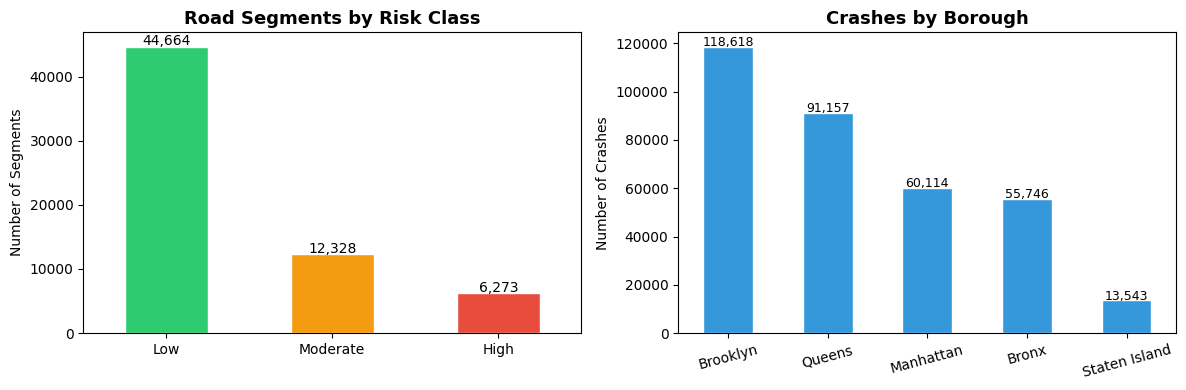

Chart saved.


In [2]:
#  Risk Class Bar Chart 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# chart 1 - risk class distribution
colors = ['#2ecc71', '#f39c12', '#e74c3c']
risk_counts[['Low','Moderate','High']].plot(
    kind='bar', ax=axes[0], color=colors, edgecolor='white'
)
axes[0].set_title('Road Segments by Risk Class', fontsize=13, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Number of Segments')
axes[0].set_xticklabels(['Low', 'Moderate', 'High'], rotation=0)
for i, v in enumerate(risk_counts[['Low','Moderate','High']]):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontsize=10)

# chart 2 - borough crash distribution
borough_counts = cleaned['borough'].value_counts().dropna()
borough_counts.plot(kind='bar', ax=axes[1], color='#3498db', edgecolor='white')
axes[1].set_title('Crashes by Borough', fontsize=13, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Number of Crashes')
axes[1].set_xticklabels(borough_counts.index, rotation=15)
for i, v in enumerate(borough_counts):
    axes[1].text(i, v + 300, f'{v:,}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig("../outputs/figures/results_summary.png", dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")